In [91]:
#Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [92]:
#Carregando as tabelas
df = pd.read_csv('dados_tratados/telemetry.csv', sep=';', encoding='latin-1')
df.head()

,id,session_id,user_id,timestamp,score,state,eye_openness,blink_rate,is_yawning,is_face_detected,...,blink_contribution,yawn_contribution,ambient_light_lux,frame_luminance,lighting_mode,head_yaw_degrees,head_pitch_degrees,hour,data,dia_semana
0,2452,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:22.353000+00:00,0.000000,CALIBRATING,0.799889,0,False,True,...,0.0,0.0,0.0,110.2660,NORMAL,NaN,NaN,20:49:22,2026-07-09,quinta-feira
1,2453,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:24.361000+00:00,0.000000,CALIBRATING,0.328411,0,False,True,...,0.0,0.0,0.0,77.9219,NORMAL,NaN,NaN,20:49:24,2026-07-09,quinta-feira
2,2454,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:26.390000+00:00,0.000000,CALIBRATING,0.000000,0,False,True,...,0.0,0.0,0.0,77.1875,NORMAL,NaN,NaN,20:49:26,2026-07-09,quinta-feira
3,2455,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:28.418000+00:00,0.000000,CALIBRATING,0.439072,0,False,True,...,0.0,0.0,0.0,70.9531,NORMAL,NaN,NaN,20:49:28,2026-07-09,quinta-feira
4,2456,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:30.438000+00:00,2.465517,NORMAL,0.471622,0,False,True,...,0.0,0.0,0.0,73.9062,NORMAL,NaN,NaN,20:49:30,2026-07-09,quinta-feira


In [93]:
# Tirando os valore "CALIBRATING"  e "NO_FACE", pois valores para o começo da viajem, ou de erro, então são registros que não precisa.

df = df[~df['state'].isin(['CALIBRATING','NO_FACE'])].copy()

#Criando mais uma coluna booleana, onde "WARNING" e "FATIGUED" é 1, pois são valores de risco e o "NORMAL" é 1.
df['risco'] = df['state'].isin(['WARNING','FATIGUED']).astype(int)


print(df['state'].value_counts())
print(df['risco'].value_counts())

state
NORMAL      52351
WARNING       276
FATIGUED       32
Name: count, dtype: int64
risco
0    52351
1      308
Name: count, dtype: int64


In [94]:
# Separando os dados para o treino e teste
X = df[['perclos', 'blink_rate', 'is_yawning', 'eye_openness','head_yaw_degrees', 'head_pitch_degrees']].fillna(0)
y = df['risco']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando nosso modelo, onde o número total de árvores é 100 e com a classe de peso balanceada
RF = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

In [95]:
#Treinando o modelo e avaliando ele

RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)
print(f'Acurácia: {accuracy_score(y_test, y_pred)*100:.2f}%')

Acurácia: 98.69%


In [96]:
acc_treino = accuracy_score(y_train, RF.predict(X_train))
acc_teste = accuracy_score(y_test, y_pred)

print(f'Acurácia treino: {acc_treino*100:.2f}%')
print(f'Acurácia teste: {acc_teste*100:.2f}%')

Acurácia treino: 99.54%
Acurácia teste: 98.69%


In [97]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10467
           1       0.10      0.14      0.12        65

    accuracy                           0.99     10532
   macro avg       0.55      0.57      0.55     10532
weighted avg       0.99      0.99      0.99     10532



**Com uma acurácia de 98,7%, parece que temos um ótimo modelo para esse projeto, mas está desbalanceada**

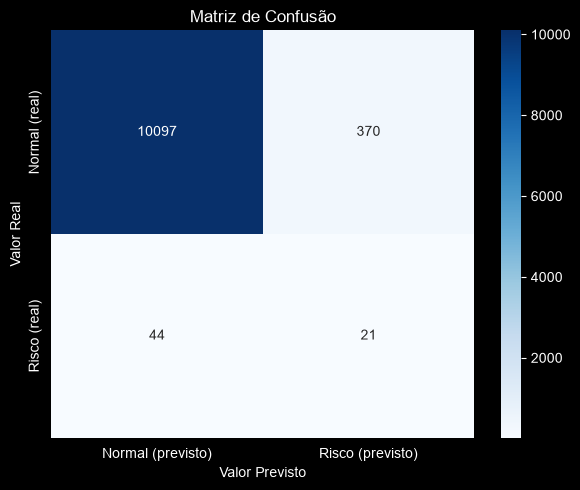

In [98]:
# Percebi que os dados continuam desbalanceados e então vou importar a biblioteca Im Balanced, com o algoritmo SMOTE, onde ele cria novos dados no grupo que é menor

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train_bal, y_train_bal)
y_pred_bal = RF.predict(X_test)

cm_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bal, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal (previsto)', 'Risco (previsto)'],
    yticklabels=['Normal (real)', 'Risco (real)']
)
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
plt.tight_layout()
plt.savefig('matriz_confusao_balanceada.png', dpi=150)
plt.show()

In [99]:
print(f'Acurácia: {accuracy_score(y_test, y_pred_bal)*100:.2f}%')

Acurácia: 96.07%


**Depois de balancear o dataset com SMOTE, a acurácia caiu de 98,7% para 96,07% — uma queda esperada e aceitável, já que a acurácia geral não é a métrica relevante nesse problema (ela era artificialmente alta por causa do desbalanceamento). O que importa é que o recall da classe de risco subiu de 14% para 38%, mostrando que o modelo balanceado é significativamente melhor em detectar casos reais de fadiga/desatenção, ao custo de mais falsos positivos (queda de precisão).**

In [100]:
probs = RF.predict_proba(X_test)[:,1]
y_pred_ajustado = (probs>0.35).astype(int)
print(classification_report(y_test, y_pred_ajustado))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     10467
           1       0.04      0.38      0.07        65

    accuracy                           0.94     10532
   macro avg       0.52      0.66      0.52     10532
weighted avg       0.99      0.94      0.96     10532



head_pitch_degrees    25.942713
head_yaw_degrees      21.276825
perclos               20.958932
eye_openness          16.071898
blink_rate            10.497019
is_yawning             5.252613
dtype: float64


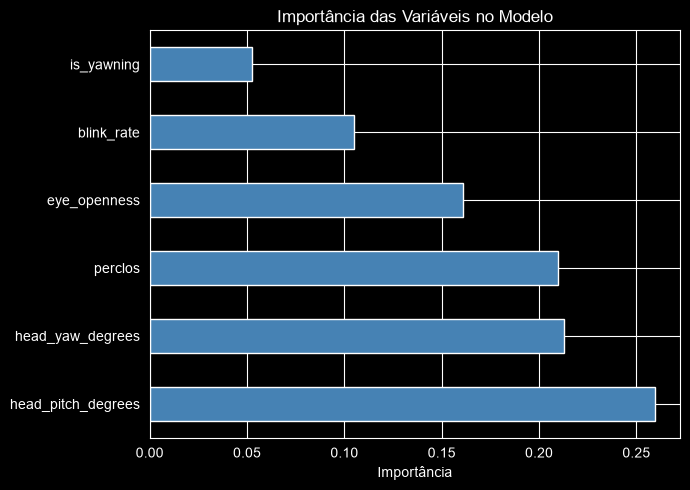

In [101]:
# Analisando qual feature mais influência no resultado

importancias = pd.Series(RF.feature_importances_, index=['perclos', 'blink_rate', 'is_yawning', 'eye_openness','head_yaw_degrees', 'head_pitch_degrees']).sort_values(ascending=False)
print(f'{importancias*100}')

importancias.plot(kind='barh', figsize=(7,5), color='steelblue')
plt.xlabel('Importância')
plt.title('Importância das Variáveis no Modelo')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [102]:
# Usando o modelo já treinado pra prever em TODA a base, não só no teste
df['prob_risco'] = RF.predict_proba(df[['perclos', 'blink_rate', 'is_yawning', 'eye_openness','head_yaw_degrees', 'head_pitch_degrees']].fillna(0))[:, 1]
df['prob_risco'] = df['prob_risco']*100

df.head()

,id,session_id,user_id,timestamp,score,state,eye_openness,blink_rate,is_yawning,is_face_detected,...,ambient_light_lux,frame_luminance,lighting_mode,head_yaw_degrees,head_pitch_degrees,hour,data,dia_semana,risco,prob_risco
4,2456,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:30.438000+00:00,2.465517,NORMAL,0.471622,0,False,True,...,0.0,73.90620,NORMAL,NaN,NaN,20:49:30,2026-07-09,quinta-feira,0,26.000000
5,2457,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:32.528000+00:00,13.634197,NORMAL,0.581924,2,False,True,...,0.0,76.64060,NORMAL,NaN,NaN,20:49:32,2026-07-09,quinta-feira,0,26.000000
6,2458,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:34.601000+00:00,15.407818,NORMAL,0.526900,5,False,True,...,0.0,77.48440,NORMAL,NaN,NaN,20:49:34,2026-07-09,quinta-feira,0,21.000000
7,2459,dab4cf30-6a7b-4968-9f38-3d6d19ac14d2,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-09 23:49:36.739000+00:00,17.543758,NORMAL,0.530796,5,False,True,...,0.0,75.34380,NORMAL,NaN,NaN,20:49:36,2026-07-09,quinta-feira,0,29.000000
12,2464,55620910-eeab-43a6-a0f6-1d67beaf484e,51ae0ca6-7aab-417c-93d4-a0af40e66654,2026-07-13 08:09:12.345000+00:00,0.000000,NORMAL,0.454280,0,False,True,...,0.0,3.53125,DARK,NaN,NaN,05:09:12,2026-07-13,segunda-feira,0,16.311915


In [103]:
df.to_excel(r'C:\Users\relia\OneDrive\Documentos\Projetos\ACEX\Jupyter\dados_tratados\aplicativo_probabilidade.xlsx')

In [104]:
df.to_csv(r'C:\Users\relia\OneDrive\Documentos\Projetos\ACEX\Jupyter\dados_tratados\aplicativo_probabilidade.csv')

In [105]:
prof = pd.read_csv('Dados/profiles_rows.csv', sep=',', encoding='latin1')
prof.head()


,id,full_name,email,created_at,tos_version,tos_accepted_at,privacy_version,privacy_accepted_at
0,03b47eef-bc6e-44ff-92e8-7a6601b0a6d7,Nubia,nubiancasousa@gmail.com,2026-09-04 20:11:02.257763+00,2026-09-04,2026-09-07 20:19:44.83898+00,2026-09-06,2026-09-07 20:19:48.475987+00
1,080ac8b0-1696-4ec9-9a50-340e42971ecc,Jeciane Rocha,jeciane@hotmail.com,2026-09-09 16:38:24.500517+00,2026-09-04,2026-09-09 16:39:04.585808+00,2026-09-06,2026-09-09 16:39:11.192593+00
2,10cbb831-2251-4fbb-b6fa-0cdad50a6dc2,Denilson Medeiros Silva,hotdog2245@outlook.com,2026-09-10 21:41:49.238562+00,2026-09-04,2026-09-10 21:41:44.225332+00,2026-09-06,2026-09-10 21:41:49.523612+00
3,505bb496-ce7b-4f68-8ea3-ed9da58cac15,MoisÃ©s Alves de Souza,moisesads@gmail.com,2026-09-08 17:54:25.925161+00,2026-09-04,2026-09-11 00:26:44.702892+00,2026-09-06,2026-09-11 00:26:50.430226+00
4,51ae0ca6-7aab-417c-93d4-a0af40e66654,AndrÃ© Luiz Barbosa,andre123.l.b.37@gmail.com,2026-07-09 23:41:02+00,NaN,NaN,NaN,NaN


In [121]:
media_prob = df.groupby(['user_id','session_id'])['prob_risco'].mean()
media_prob = pd.DataFrame(media_prob)
media_prob = media_prob.reset_index()
media_prob =  media_prob.rename(columns={'user_id':'id'})
user_prob = prof.merge(media_prob,on='id',how='outer').fillna(0)
user_prob.head()

,id,full_name,email,created_at,tos_version,tos_accepted_at,privacy_version,privacy_accepted_at,session_id,prob_risco
0,03b47eef-bc6e-44ff-92e8-7a6601b0a6d7,Nubia,nubiancasousa@gmail.com,2026-09-04 20:11:02.257763+00,2026-09-04,2026-09-07 20:19:44.83898+00,2026-09-06,2026-09-07 20:19:48.475987+00,0,0.000000
1,080ac8b0-1696-4ec9-9a50-340e42971ecc,Jeciane Rocha,jeciane@hotmail.com,2026-09-09 16:38:24.500517+00,2026-09-04,2026-09-09 16:39:04.585808+00,2026-09-06,2026-09-09 16:39:11.192593+00,0c505f9c-4aa0-43d0-8047-1d0c5cc6fe2d,13.086820
2,080ac8b0-1696-4ec9-9a50-340e42971ecc,Jeciane Rocha,jeciane@hotmail.com,2026-09-09 16:38:24.500517+00,2026-09-04,2026-09-09 16:39:04.585808+00,2026-09-06,2026-09-09 16:39:11.192593+00,4460a316-4364-4a57-aa6e-0840316b4b22,6.017488
3,080ac8b0-1696-4ec9-9a50-340e42971ecc,Jeciane Rocha,jeciane@hotmail.com,2026-09-09 16:38:24.500517+00,2026-09-04,2026-09-09 16:39:04.585808+00,2026-09-06,2026-09-09 16:39:11.192593+00,cb04fa3d-2752-4690-bc06-c0002528d817,3.207663
4,080ac8b0-1696-4ec9-9a50-340e42971ecc,Jeciane Rocha,jeciane@hotmail.com,2026-09-09 16:38:24.500517+00,2026-09-04,2026-09-09 16:39:04.585808+00,2026-09-06,2026-09-09 16:39:11.192593+00,ce3205ed-149e-4b60-9135-2bc17bb28ceb,3.851153


In [124]:
media_prob_user = user_prob.groupby(['id','full_name'])['prob_risco'].mean()
media_prob_user = media_prob_user.reset_index()
media_prob_user.head()

,id,full_name,prob_risco
0,03b47eef-bc6e-44ff-92e8-7a6601b0a6d7,Nubia,0.000000
1,080ac8b0-1696-4ec9-9a50-340e42971ecc,Jeciane Rocha,6.540781
2,10cbb831-2251-4fbb-b6fa-0cdad50a6dc2,Denilson Medeiros Silva,5.113703
3,505bb496-ce7b-4f68-8ea3-ed9da58cac15,MoisÃ©s Alves de Souza,12.379173
4,51ae0ca6-7aab-417c-93d4-a0af40e66654,AndrÃ© Luiz Barbosa,29.677855


In [156]:
media_prob_user = media_prob_user.rename(columns={'id':'user_id'})
data_prob = df.merge(media_prob_user, on='user_id', how='inner')
data_prob = data_prob.groupby(['full_name', 'data'])['prob_risco_x'].mean()
data_prob = data_prob.reset_index()
data_prob = data_prob.rename(columns={'prob_risco_x':'prob_risco'})
data_prob = pd.DataFrame(data_prob)
data_prob.head()

,full_name,data,prob_risco
0,AndrÃ© Luiz Barbosa,2026-07-09,25.500000
1,AndrÃ© Luiz Barbosa,2026-07-13,33.855711
2,Denilson Medeiros Silva,2026-09-09,10.827011
3,Denilson Medeiros Silva,2026-09-10,3.615583
4,Denilson Medeiros Silva,2026-09-12,5.150816


In [153]:
data_prob.to_csv(r'C:\Users\relia\OneDrive\Documentos\Projetos\ACEX\Jupyter\dados_tratados\porb_data.csv')

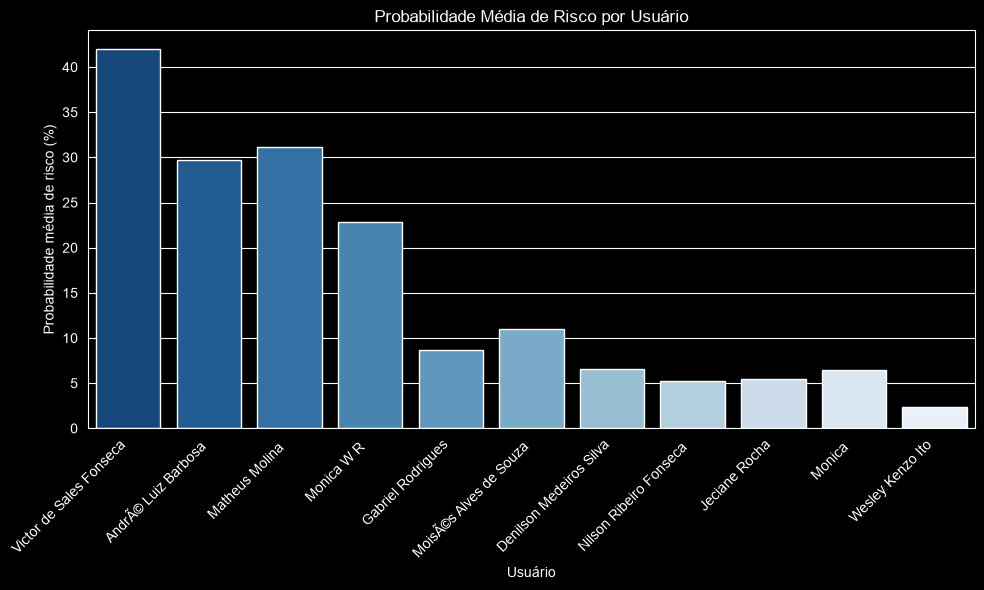

In [154]:
data_prob_ordenado = data_prob.sort_values('prob_risco', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='full_name', y='prob_risco', data=data_prob_ordenado, palette='Blues_r', hue='full_name',legend=False, errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Usuário')
plt.ylabel('Probabilidade média de risco (%)')
plt.title('Probabilidade Média de Risco por Usuário')
plt.tight_layout()
plt.savefig('prob_por_usuario.png', dpi=150)
plt.show()